# 03. Workplace Dynamics & Job Satisfaction

This notebook details workplace dynamics and professional satisfaction. We examine:
1. Remote vs. Hybrid vs. In-person work trends (2021-2025)
2. Workplace setups by organization size
3. Job Satisfaction distributions
4. Relationship between remote work and job satisfaction

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Remote Work Evolution (2021-2025)

Let's trace how the preference for remote/hybrid/in-person has shifted over the last five years.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


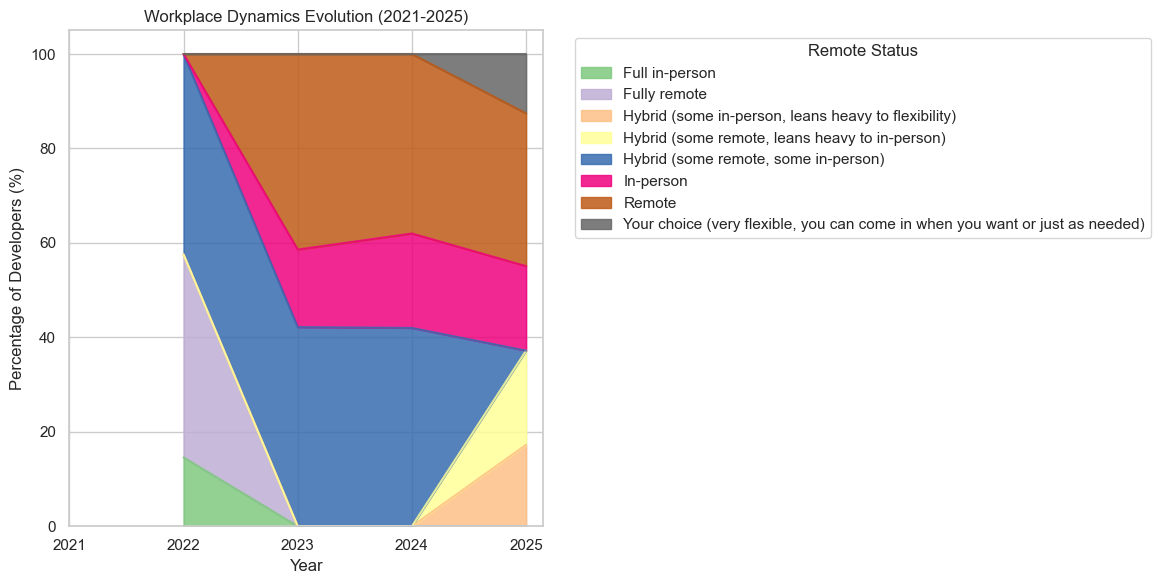

In [ ]:
remote_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    emp.RemoteWork,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown' AND emp.RemoteWork <> ''
GROUP BY YEAR(f.SurveyYear), emp.RemoteWork;
"""
df_remote = db.read_query(remote_query)

if df_remote is not None and not df_remote.empty:
    df_pivot = df_remote.pivot(index='Year', columns='RemoteWork', values='Count').fillna(0)
    df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    plt.figure(figsize=(12, 6))
    df_pivot_pct.plot(kind='area', stacked=True, alpha=0.85, colormap='Accent', ax=plt.gca())
    plt.title('Workplace Dynamics Evolution (2022-2025)')
    plt.xlabel('Year')
    plt.ylabel('Percentage of Developers (%)')
    plt.xticks([ 2022, 2023, 2024, 2025])
    plt.legend(title='Remote Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_remote_work_trends.png'), dpi=300)
    plt.show()
else:
    print("No remote work data available.")

### 2. Workplace Setting by Organization Size (2025)

Do larger companies require more in-person work than small businesses?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


IndexError: index 0 is out of bounds for axis 0 with size 0

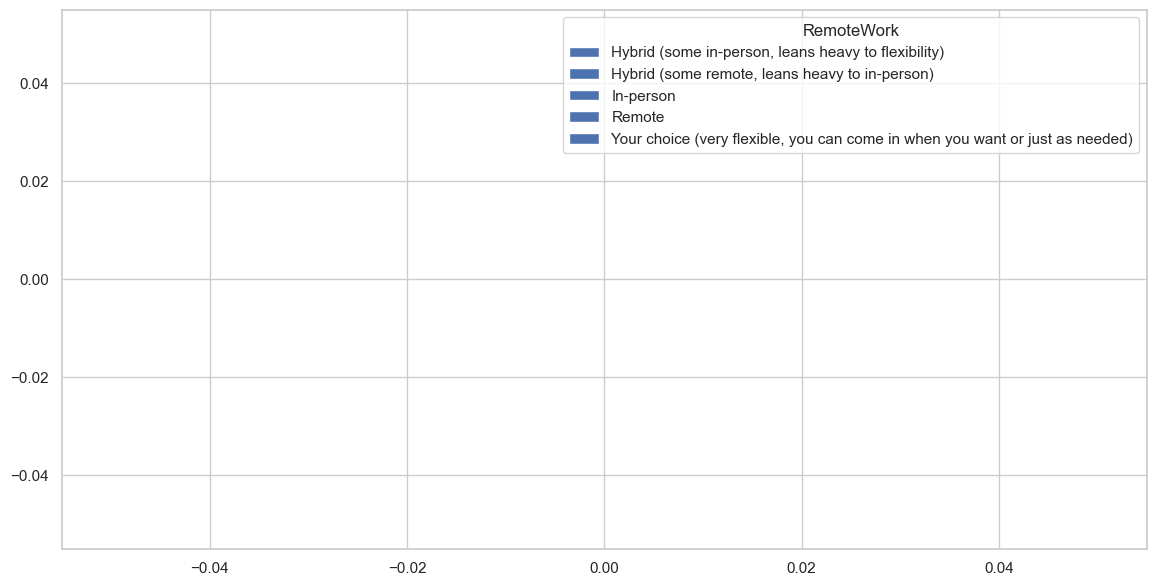

In [3]:
org_work_query = """
SELECT 
    emp.Organization_Size,
    emp.RemoteWork,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE YEAR(f.SurveyYear) = 2025
  AND emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown' AND emp.RemoteWork <> ''
  AND emp.Organization_Size IS NOT NULL AND emp.Organization_Size <> 'Unknown' AND emp.Organization_Size <> ''
GROUP BY emp.Organization_Size, emp.RemoteWork;
"""
df_org_work = db.read_query(org_work_query)

if df_org_work is not None and not df_org_work.empty:
    df_org_pivot = df_org_work.pivot(index='Organization_Size', columns='RemoteWork', values='Count').fillna(0)
    # Order by size
    size_order = [
        'Just me - 1 person', 
        '2 to 9 employees', 
        '10 to 19 employees', 
        '20 to 99 employees', 
        '100 to 499 employees', 
        '500 to 999 employees', 
        '1,000 to 4,999 employees', 
        '5,000 to 9,999 employees', 
        '10,000 or more employees'
    ]
    df_org_pivot = df_org_pivot.reindex(size_order).dropna()
    df_org_pct = df_org_pivot.div(df_org_pivot.sum(axis=1), axis=0) * 100
    
    df_org_pct.plot(kind='barh', stacked=True, figsize=(14, 7), colormap='Set3')
    plt.title('Workplace Setting by Organization Size (2025)')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Organization Size')
    plt.legend(title='Remote Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_remote_by_org_size.png'), dpi=300)
    plt.show()
else:
    print("No remote/org data available.")

### 3. Job Satisfaction Distribution

How satisfied are developers with their current roles overall?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


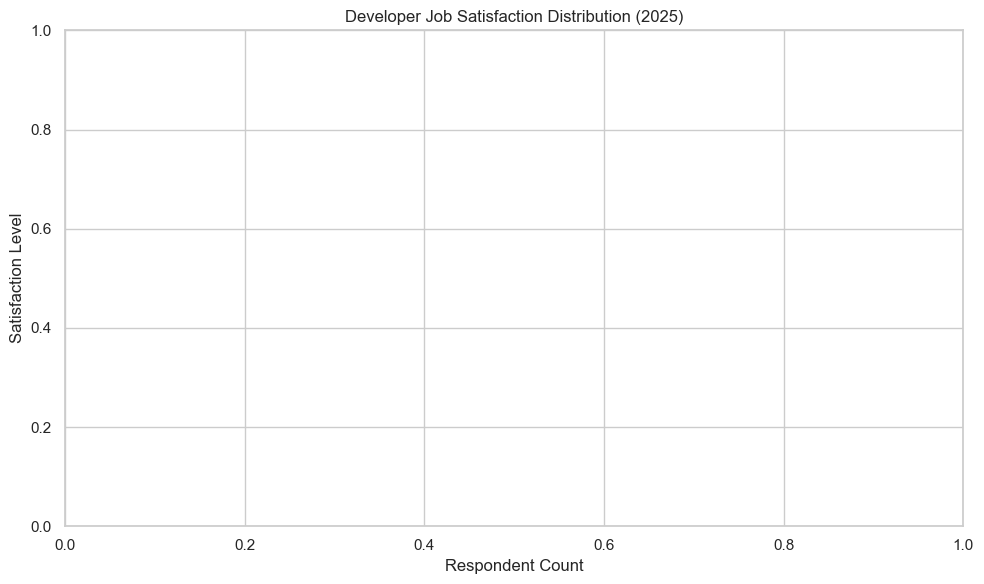

In [4]:
sat_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    sat.JobSat,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Satisfaction sat ON f.Dim_SatisfactionID = sat.Dim_SatisfactionID
WHERE sat.JobSat IS NOT NULL AND sat.JobSat <> 'Unknown' AND sat.JobSat <> ''
GROUP BY YEAR(f.SurveyYear), sat.JobSat;
"""
df_sat = db.read_query(sat_query)

if df_sat is not None and not df_sat.empty:
    df_sat_2025 = df_sat[df_sat['Year'] == 2025].copy()
    order = ['Very satisfied', 'Slightly satisfied', 'Neither satisfied nor dissatisfied', 'Slightly dissatisfied', 'Very dissatisfied']
    df_sat_2025 = df_sat_2025.set_index('JobSat').reindex(order).dropna().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_sat_2025, x='Count', y='JobSat', palette='viridis')
    plt.title('Developer Job Satisfaction Distribution (2025)')
    plt.xlabel('Respondent Count')
    plt.ylabel('Satisfaction Level')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_job_satisfaction.png'), dpi=300)
    plt.show()
else:
    print("No satisfaction data available.")

### 4. Job Satisfaction vs. Workplace Setup

Does remote work have a correlation with job satisfaction?

In [5]:
remote_sat_query = """
SELECT 
    emp.RemoteWork,
    sat.JobSat,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
JOIN Snowflake.Dim_Satisfaction sat ON f.Dim_SatisfactionID = sat.Dim_SatisfactionID
WHERE YEAR(f.SurveyYear) = 2025
  AND emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown'
  AND sat.JobSat IS NOT NULL AND sat.JobSat <> 'Unknown'
GROUP BY emp.RemoteWork, sat.JobSat;
"""
df_remote_sat = db.read_query(remote_sat_query)

if df_remote_sat is not None and not df_remote_sat.empty:
    df_rs_pivot = df_remote_sat.pivot(index='RemoteWork', columns='JobSat', values='Count').fillna(0)
    sat_order = ['Very satisfied', 'Slightly satisfied', 'Neither satisfied nor dissatisfied', 'Slightly dissatisfied', 'Very dissatisfied']
    df_rs_pivot = df_rs_pivot[sat_order]
    df_rs_pct = df_rs_pivot.div(df_rs_pivot.sum(axis=1), axis=0) * 100
    
    df_rs_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlGn_r')
    plt.title('Job Satisfaction by Workplace Setup (2025)')
    plt.xlabel('Workplace Setup')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_satisfaction_by_workplace.png'), dpi=300)
    plt.show()
else:
    print("No satisfaction/workplace data available.")

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


KeyError: "None of [Index(['Very satisfied', 'Slightly satisfied',\n       'Neither satisfied nor dissatisfied', 'Slightly dissatisfied',\n       'Very dissatisfied'],\n      dtype='object', name='JobSat')] are in the [columns]"

In [ ]:
db.close()